In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df=pd.read_csv('/content/drive/MyDrive/ML-DL/Datasets/New_Dataset.csv')

In [5]:
df

,timestamp,user_id,ip_address,device_type,browser,failure_reason,auth_type,threat_level
0,2025-07-23 00:10:24,6a214818-e78e-47fc-a728-226c70b18e37,148.6.34.231,Tablet,Edge,Account Locked,Token,10
1,2025-12-09 12:43:10,6ad7f4f8-3b0b-45c8-b6aa-2cf6a10b2040,134.106.53.46,PC,Edge,NaN,Biometric,5
2,2025-04-10 04:15:24,ec4aa120-d196-45af-98ca-4a13ec08d354,164.233.90.226,PC,Firefox,NaN,Password,10
3,2026-02-13 02:22:46,71041fa0-b11c-4df8-ace3-59a60b13d613,205.62.126.123,PC,Chrome,NaN,Biometric,3
4,2025-02-15 12:41:34,130c32b7-28e7-4d6c-99e0-2e17a439550e,157.225.10.229,PC,Safari,NaN,Password,9
...,...,...,...,...,...,...,...,...
570,2025-02-23 13:00:23,2a6bafe1-cdbb-40b8-b928-c8aa266d2b45,1.117.154.232,Tablet,Edge,NaN,Biometric,8
571,2025-04-03 02:03:27,43f87eb7-dfaa-42d2-92e7-198ef97be769,121.107.237.198,PC,Firefox,NaN,Password,7
572,2025-04-12 08:52:26,256986ee-0625-4df0-9d36-f284d7e84580,92.86.249.189,Tablet,Opera,NaN,Biometric,7
573,2025-08-08 17:51:27,c8f63500-b0d7-4d47-9189-9db03a4f3c24,145.233.76.204,Tablet,Safari,NaN,Biometric,0


In [6]:
df.head()

,timestamp,user_id,ip_address,device_type,browser,failure_reason,auth_type,threat_level
0,2025-07-23 00:10:24,6a214818-e78e-47fc-a728-226c70b18e37,148.6.34.231,Tablet,Edge,Account Locked,Token,10
1,2025-12-09 12:43:10,6ad7f4f8-3b0b-45c8-b6aa-2cf6a10b2040,134.106.53.46,PC,Edge,NaN,Biometric,5
2,2025-04-10 04:15:24,ec4aa120-d196-45af-98ca-4a13ec08d354,164.233.90.226,PC,Firefox,NaN,Password,10
3,2026-02-13 02:22:46,71041fa0-b11c-4df8-ace3-59a60b13d613,205.62.126.123,PC,Chrome,NaN,Biometric,3
4,2025-02-15 12:41:34,130c32b7-28e7-4d6c-99e0-2e17a439550e,157.225.10.229,PC,Safari,NaN,Password,9


In [7]:
df.tail()

,timestamp,user_id,ip_address,device_type,browser,failure_reason,auth_type,threat_level
570,2025-02-23 13:00:23,2a6bafe1-cdbb-40b8-b928-c8aa266d2b45,1.117.154.232,Tablet,Edge,NaN,Biometric,8
571,2025-04-03 02:03:27,43f87eb7-dfaa-42d2-92e7-198ef97be769,121.107.237.198,PC,Firefox,NaN,Password,7
572,2025-04-12 08:52:26,256986ee-0625-4df0-9d36-f284d7e84580,92.86.249.189,Tablet,Opera,NaN,Biometric,7
573,2025-08-08 17:51:27,c8f63500-b0d7-4d47-9189-9db03a4f3c24,145.233.76.204,Tablet,Safari,NaN,Biometric,0
574,2025-06-20 12:25:21,6ef16204-4de3-4cd7-b7fb-7029ac21e627,182.217.83.136,Mobile,Safari,Account Locked,Password,10


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       575 non-null    object
 1   user_id         575 non-null    object
 2   ip_address      575 non-null    object
 3   device_type     575 non-null    object
 4   browser         575 non-null    object
 5   failure_reason  222 non-null    object
 6   auth_type       575 non-null    object
 7   threat_level    575 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 36.1+ KB


In [9]:
df.isnull().sum()

,0
timestamp,0
user_id,0
ip_address,0
device_type,0
browser,0
failure_reason,353
auth_type,0
threat_level,0


In [10]:
df.shape

(575, 8)

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['failure_reason']=le.fit_transform(df['failure_reason'])
df['browser'] = le.fit_transform(df['browser'])
df['auth_type'] = le.fit_transform(df['auth_type'])
df['device_type'] = le.fit_transform(df['device_type'])

In [12]:
df

,timestamp,user_id,ip_address,device_type,browser,failure_reason,auth_type,threat_level
0,2025-07-23 00:10:24,6a214818-e78e-47fc-a728-226c70b18e37,148.6.34.231,2,1,0,2,10
1,2025-12-09 12:43:10,6ad7f4f8-3b0b-45c8-b6aa-2cf6a10b2040,134.106.53.46,1,1,3,0,5
2,2025-04-10 04:15:24,ec4aa120-d196-45af-98ca-4a13ec08d354,164.233.90.226,1,2,3,1,10
3,2026-02-13 02:22:46,71041fa0-b11c-4df8-ace3-59a60b13d613,205.62.126.123,1,0,3,0,3
4,2025-02-15 12:41:34,130c32b7-28e7-4d6c-99e0-2e17a439550e,157.225.10.229,1,4,3,1,9
...,...,...,...,...,...,...,...,...
570,2025-02-23 13:00:23,2a6bafe1-cdbb-40b8-b928-c8aa266d2b45,1.117.154.232,2,1,3,0,8
571,2025-04-03 02:03:27,43f87eb7-dfaa-42d2-92e7-198ef97be769,121.107.237.198,1,2,3,1,7
572,2025-04-12 08:52:26,256986ee-0625-4df0-9d36-f284d7e84580,92.86.249.189,2,3,3,0,7
573,2025-08-08 17:51:27,c8f63500-b0d7-4d47-9189-9db03a4f3c24,145.233.76.204,2,4,3,0,0


In [13]:
df["failure_reason"]=df["failure_reason"].fillna(df["failure_reason"].mean())

In [14]:
df.isnull().sum()

,0
timestamp,0
user_id,0
ip_address,0
device_type,0
browser,0
failure_reason,0
auth_type,0
threat_level,0


In [15]:
print(df.duplicated().sum())

0


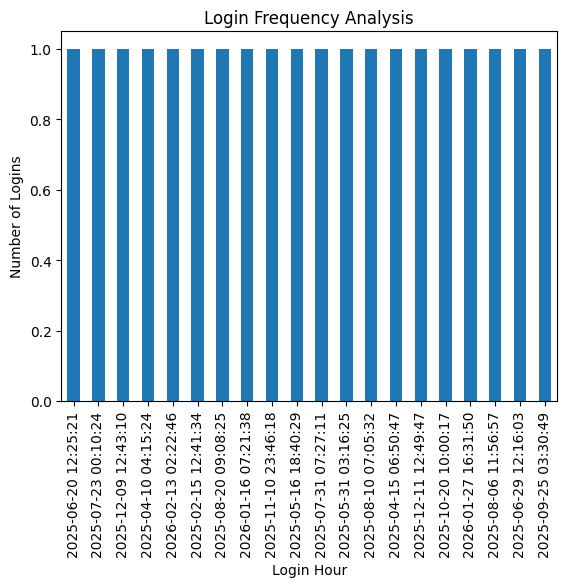

In [16]:
df['timestamp'].value_counts().head(20).plot(kind='bar')
plt.xlabel("Login Hour")
plt.ylabel("Number of Logins")
plt.title("Login Frequency Analysis")
plt.show()

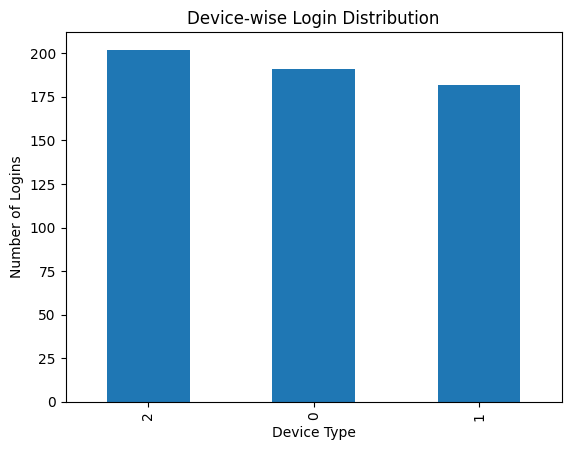

In [17]:
df['device_type'].value_counts().plot(kind='bar')
plt.xlabel("Device Type")
plt.ylabel("Number of Logins")
plt.title("Device-wise Login Distribution")
plt.show()

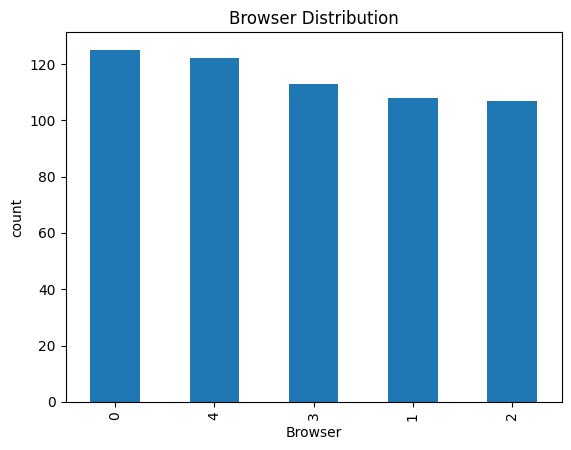

In [18]:
df['browser'].value_counts().plot(kind='bar')
plt.xlabel("Browser")
plt.ylabel("count")
plt.title("Browser Distribution")
plt.show()

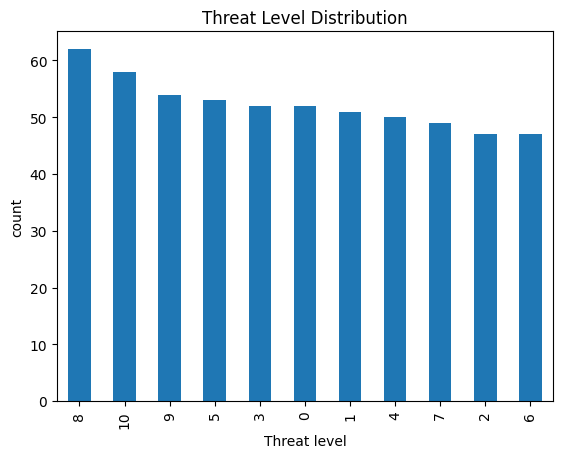

In [19]:
df['threat_level'].value_counts().plot(kind='bar')
plt.xlabel("Threat level")
plt.ylabel("count")
plt.title("Threat Level Distribution")
plt.show()

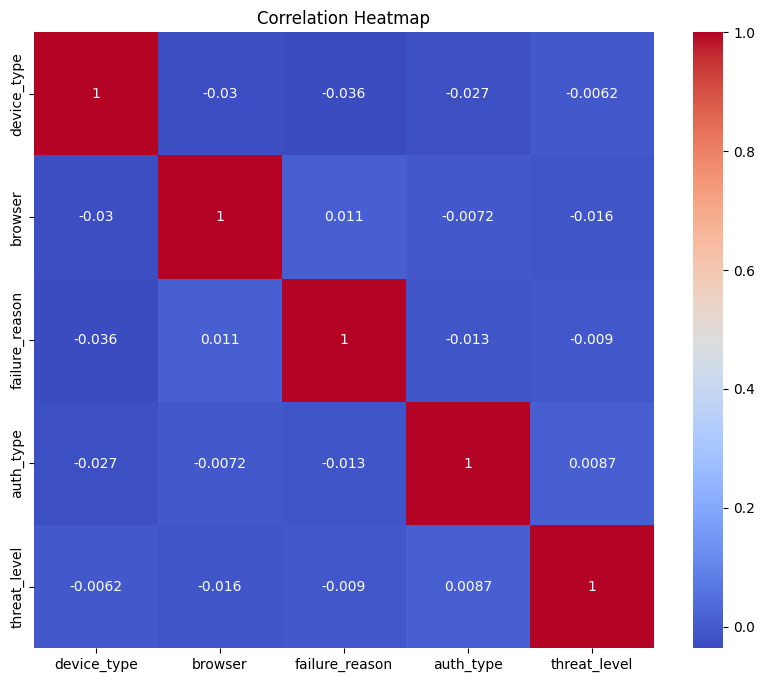

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap( df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

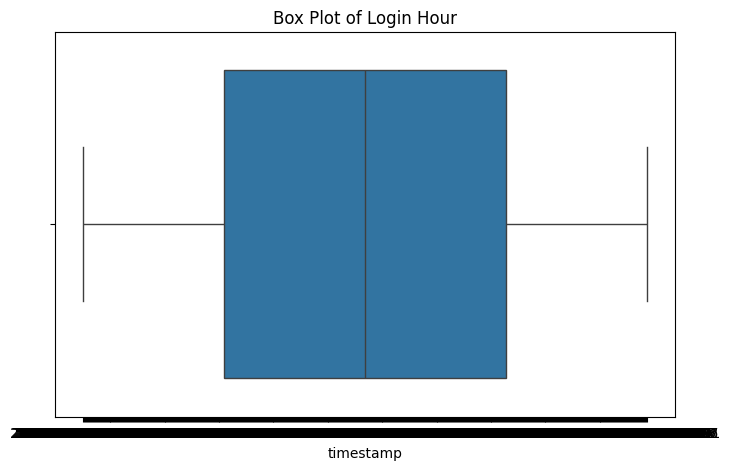

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["timestamp"])
plt.title("Box Plot of Login Hour")
plt.show()

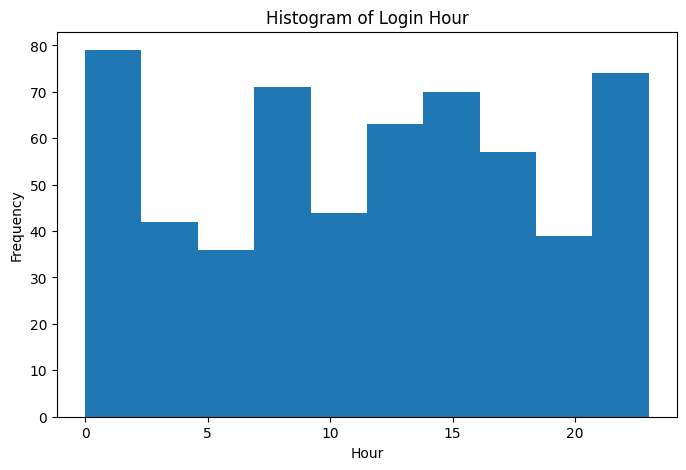

In [22]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['login_hour'] = df['timestamp'].dt.hour
plt.figure(figsize=(8,5))
plt.hist(df["login_hour"])
plt.title("Histogram of Login Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()

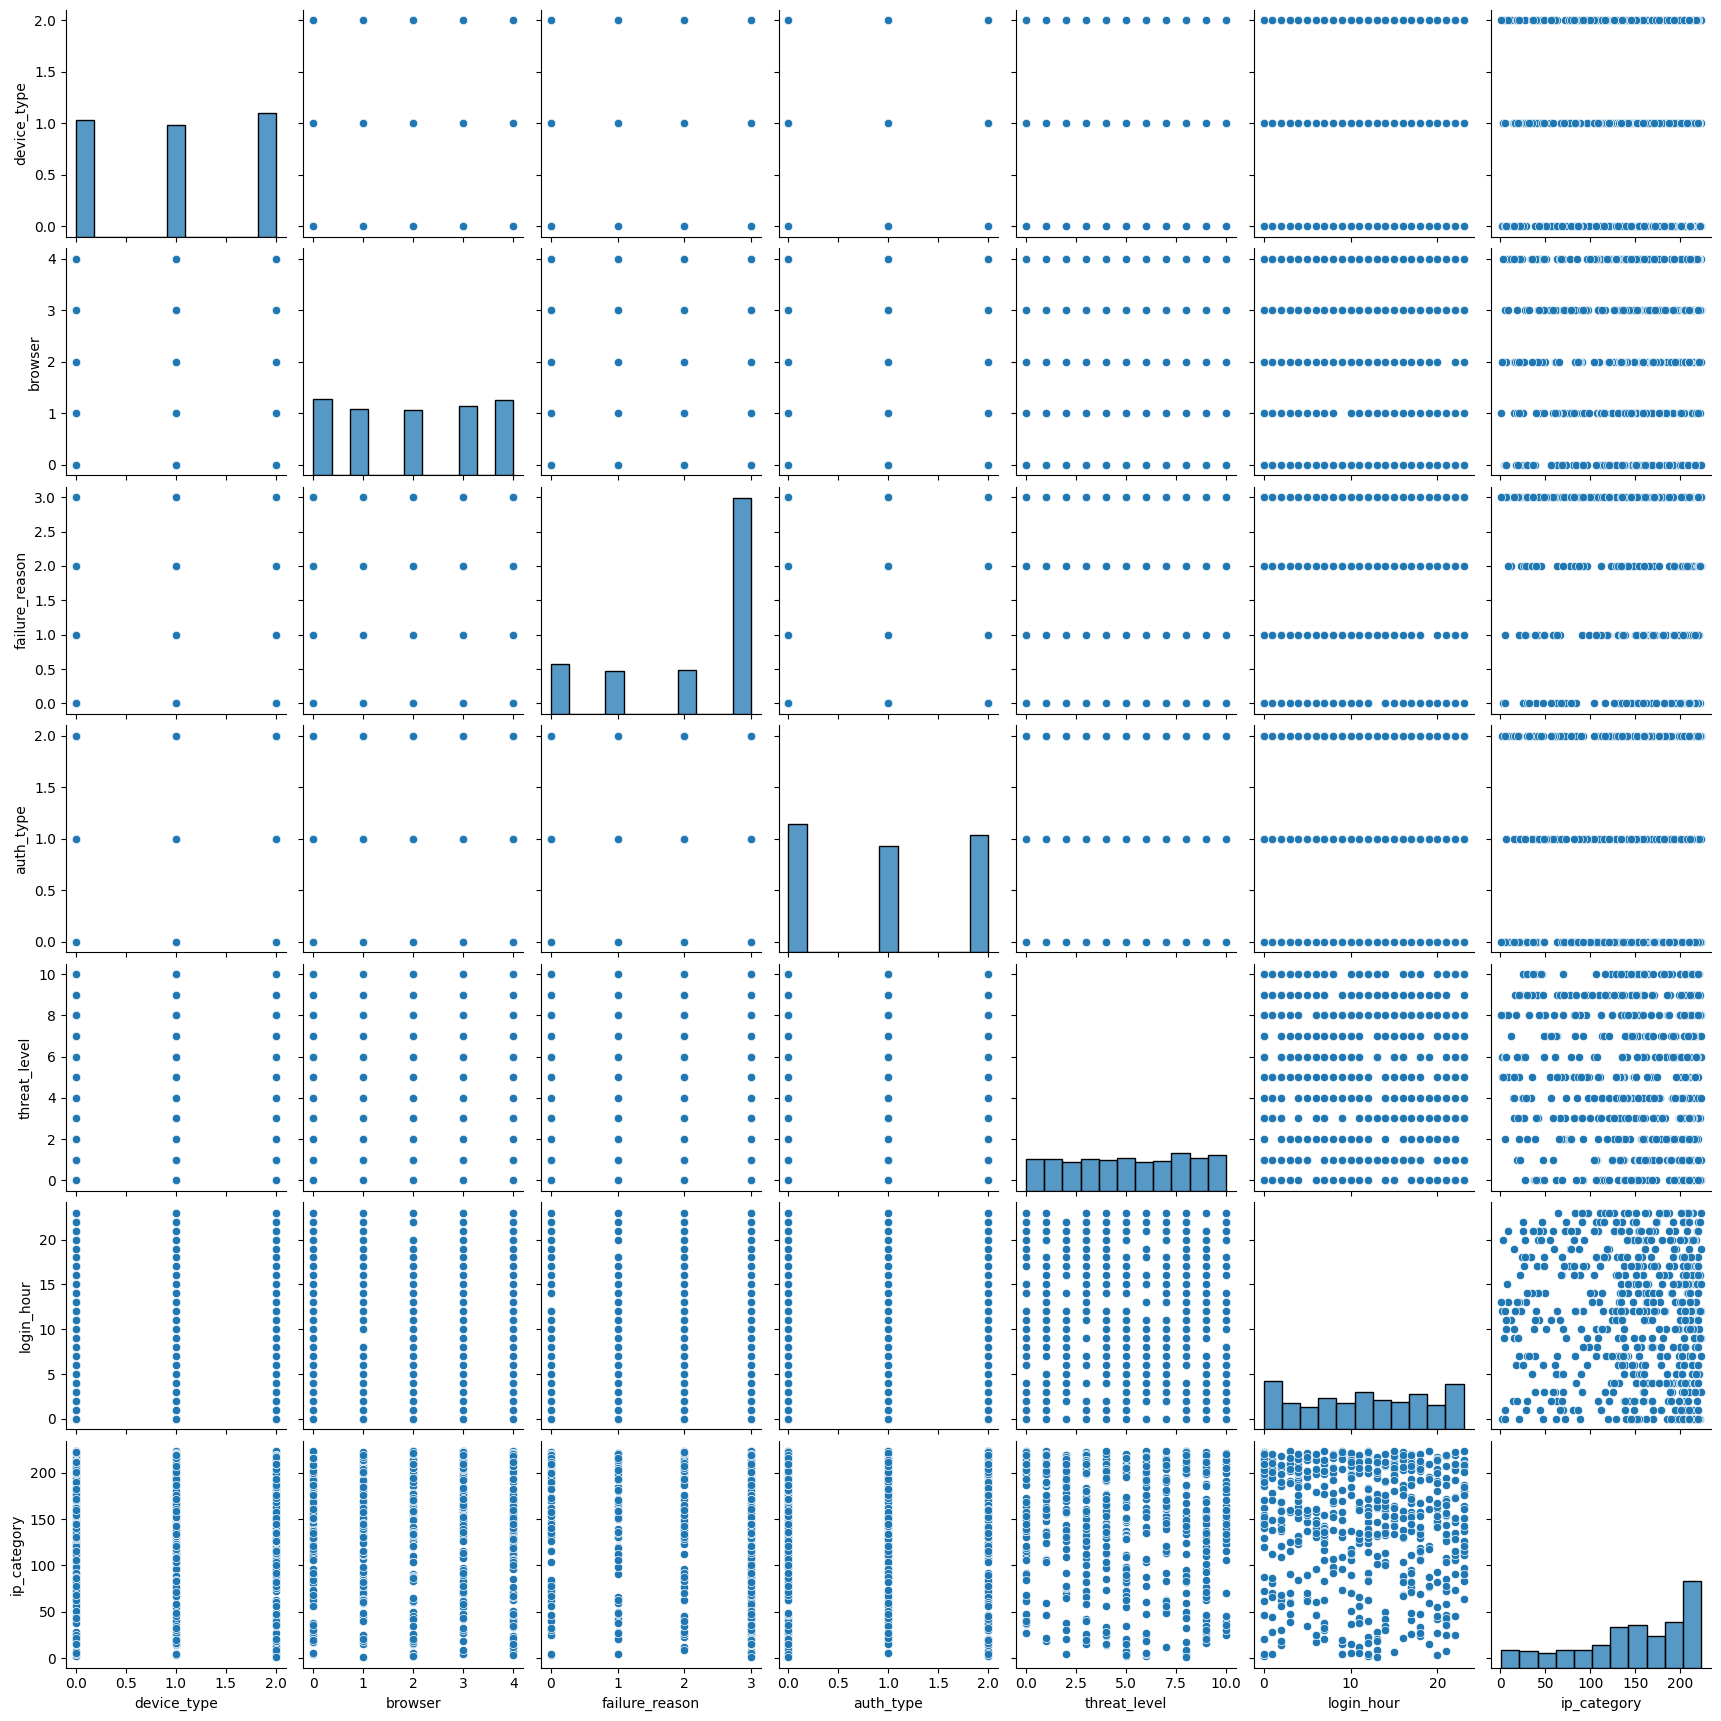

In [23]:
df['ip_category'] = df['ip_address'].apply(lambda x: int(x.split('.')[0]) if pd.notnull(x) else 0)
sns.pairplot(df)
plt.show()

FEATURE SELECTION

In [24]:
x=df.drop(['threat_level','timestamp','user_id','ip_address'],axis=1)
y=df["threat_level"]
print("features")
print(x.columns)

features
Index(['device_type', 'browser', 'failure_reason', 'auth_type', 'login_hour',
       'ip_category'],
      dtype='object')


In [25]:
y = df["threat_level"]
print(y)

0      10
1       5
2      10
3       3
4       9
       ..
570     8
571     7
572     7
573     0
574    10
Name: threat_level, Length: 575, dtype: int64


In [26]:
x

,device_type,browser,failure_reason,auth_type,login_hour,ip_category
0,2,1,0,2,0,148
1,1,1,3,0,12,134
2,1,2,3,1,4,164
3,1,0,3,0,2,205
4,1,4,3,1,12,157
...,...,...,...,...,...,...
570,2,1,3,0,13,1
571,1,2,3,1,2,121
572,2,3,3,0,8,92
573,2,4,3,0,17,145


In [27]:
y


,threat_level
0,10
1,5
2,10
3,3
4,9
...,...
570,8
571,7
572,7
573,0


In [62]:
print("Input Features:")
print(x.columns)

print("\nTarget Variable:")
print(y.head())

Input Features:
Index(['device_type', 'browser', 'failure_reason', 'auth_type', 'login_hour',
       'ip_category'],
      dtype='object')

Target Variable:
0    10
1     5
2    10
3     3
4     9
Name: threat_level, dtype: int64


TRAIN-TEST-SPILT

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Features :", x_train.shape)
print("Testing Features :", x_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (460, 6)
Testing Features : (115, 6)
Training Target : (460,)
Testing Target : (115,)


In [63]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

LOGISTIC REGRESSION


In [31]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [32]:
print("Logistic Regression")
lr_accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy :", lr_accuracy)
print("recall :", recall_score(y_test, lr_pred, average='weighted'))
print("precision :", precision_score(y_test, lr_pred, average='weighted'))
print("f1 score :", f1_score(y_test, lr_pred, average='weighted'))

Logistic Regression
Accuracy : 0.0782608695652174
recall : 0.0782608695652174
precision : 0.09260869565217392
f1 score : 0.07291896543612791


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


DECISION TREEE CLASSIFIER


In [33]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)

In [34]:
print("Decision Tree Classifier")
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy :", dt_accuracy)
print("recall :", recall_score(y_test, dt_pred, average='weighted'))
print("precision :", precision_score(y_test, dt_pred, average='weighted'))
print("f1 score :", f1_score(y_test, dt_pred, average='weighted'))

Decision Tree Classifier
Accuracy : 0.05217391304347826
recall : 0.05217391304347826
precision : 0.05765527950310559
f1 score : 0.05179614467306064


RANDOM FOREST CLASSIFIER


In [35]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [36]:
print("Random Forest Classifier")
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy :", rf_accuracy)
print("recall :", recall_score(y_test, rf_pred, average='weighted'))
print("precision :", precision_score(y_test, rf_pred, average='weighted'))
print("f1 score :", f1_score(y_test, rf_pred, average='weighted'))

Random Forest Classifier
Accuracy : 0.0782608695652174
recall : 0.0782608695652174
precision : 0.07293677337155598
f1 score : 0.07224113728186768


K NEIGHBORS CLASSIFIER


In [37]:
kn= KNeighborsClassifier()
kn.fit(x_train, y_train)
kn_pred = kn.predict(x_test)

In [38]:
print("K Neighbors Classifier")
knn_accuracy = accuracy_score(y_test, kn_pred)
print("Accuracy :", knn_accuracy)
print("recall :", recall_score(y_test, kn_pred, average='weighted'))
print("precision :", precision_score(y_test, kn_pred, average='weighted'))
print("f1 score :", f1_score(y_test, kn_pred, average='weighted'))

K Neighbors Classifier
Accuracy : 0.10434782608695652
recall : 0.10434782608695652
precision : 0.10597567649741563
f1 score : 0.0917732003755636


XGB CLASSIFIER

In [39]:
classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)
classifier.fit(x_train, y_train)
xgb_pred = classifier.predict(x_test)
print("Model Trained Successfully")

Model Trained Successfully


In [40]:
print("XGB Classifier")
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print("Accuracy :", xgb_accuracy)
print("recall :", recall_score(y_test, xgb_pred, average='weighted'))
print("precision :", precision_score(y_test, xgb_pred, average='weighted'))
print("f1 score :", f1_score(y_test, xgb_pred, average='weighted'))

XGB Classifier
Accuracy : 0.11304347826086956
recall : 0.11304347826086956
precision : 0.14069414884632278
f1 score : 0.11989932256563028


In [41]:
y_pred = xgb_pred
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy: ",accuracy)
print("Accuracy percentage :",accuracy*100)

Accuracy:  0.11304347826086956
Accuracy percentage : 11.304347826086957


CONFUSION MATRIX


In [42]:
y_pred = xgb_pred
confusion_matrix=confusion_matrix(y_test,y_pred)
print(confusion_matrix)

[[2 1 1 0 2 0 0 3 2 1 2]
 [0 1 1 1 2 0 1 0 0 1 2]
 [0 0 0 1 0 0 0 3 1 1 2]
 [1 1 1 2 2 2 1 0 1 1 0]
 [0 1 2 0 1 1 0 1 2 0 1]
 [0 1 0 1 1 1 2 1 1 2 1]
 [0 2 2 0 1 0 1 3 1 0 1]
 [2 0 1 0 1 0 1 2 4 0 1]
 [1 1 1 0 0 0 1 1 1 1 2]
 [2 1 1 1 0 0 0 0 0 1 0]
 [0 1 2 0 1 2 2 1 3 1 1]]


CLASSIFICATION REPORT

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.14      0.18        14
           1       0.10      0.11      0.11         9
           2       0.00      0.00      0.00         8
           3       0.33      0.17      0.22        12
           4       0.09      0.11      0.10         9
           5       0.17      0.09      0.12        11
           6       0.11      0.09      0.10        11
           7       0.13      0.17      0.15        12
           8       0.06      0.11      0.08         9
           9       0.11      0.17      0.13         6
          10       0.08      0.07      0.07        14

    accuracy                           0.11       115
   macro avg       0.13      0.11      0.11       115
weighted avg       0.14      0.11      0.12       115



MODEL ACCURACY COMPARISON


In [44]:
accuracy = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]

})

accuracy

,Model,Accuracy
0,Logistic Regression,0.078261
1,Decision Tree,0.052174
2,Random Forest,0.078261
3,KNN,0.104348
4,XGBoost,0.113043


In [45]:
print("Best Accuracy :", accuracy["Accuracy"].max())

Best Accuracy : 0.11304347826086956


In [46]:
best_model = accuracy.loc[
    accuracy["Accuracy"].idxmax()
]
print(best_model)

Model        XGBoost
Accuracy    0.113043
Name: 4, dtype: object


PREDICTION


In [47]:
predictions=classifier.predict(x_test)
print(predictions)

[ 7 10  2  3 10  7 10  6  6  7  3  2  9  8  7  1  6  0  4  7 10  1 10  5
  8  8  3  2  6  9  4  7  1  0  5  2  7 10  8  0  3  7  7 10  9  4  7  6
  2  8  2  1  8  5  2  7  5  6  1  2  8  5  2  4  0 10 10  5  8  9  2  0
  8  8  6  8  1 10  1  3  7  9  0  9  4  7  1 10  4  6  8  2  4  9  8  3
  7  8  9  8  4  8 10  1 10  1  6  4  9  2  0  0  4  4  7]


CREATE NEW INPUT DATA


In [48]:
new_data = pd.DataFrame({
    "login_hour": [2],
    "device_type": [1],
    "browser": [0],
    "failure_reason": [1],
    "auth_type": [0],
    "ip_category": [10]
})
new_data = new_data[x.columns]

print(x.columns)
print(new_data.columns)

Index(['device_type', 'browser', 'failure_reason', 'auth_type', 'login_hour',
       'ip_category'],
      dtype='object')
Index(['device_type', 'browser', 'failure_reason', 'auth_type', 'login_hour',
       'ip_category'],
      dtype='object')


In [49]:
new_data = pd.DataFrame({
    "login_hour": [2],
    "device_type": [1],
    "browser": [0],
    "failure_reason": [1],
    "auth_type": [0],
    "ip_category": [10]
})

In [50]:
new_data = new_data[x.columns]

PREDICTION

In [51]:
new_data_scaled = scaler.transform(new_data)
prediction = classifier.predict(new_data_scaled)
print("Predicted Threat Level:", prediction[0])

Predicted Threat Level: 8


In [52]:
prediction = classifier.predict(new_data_scaled)

In [53]:
risk = {0: "Low", 1: "Medium", 2: "High", 3: "High", 4: "High", 5: "Medium", 6: "High", 7: "High", 8: "High", 9: "High", 10: "High"}

print("========== LOGIN DETAILS ==========")
print("Login Hour :", new_data["login_hour"].iloc[0])
print("Device Type :", new_data["device_type"].iloc[0])
print("Browser :", new_data["browser"].iloc[0])
print("Failure Reason :", new_data["failure_reason"].iloc[0])
print("Authentication Type :", new_data["auth_type"].iloc[0])
print("IP Category :", new_data["ip_category"].iloc[0])
print()
print("Predicted Threat Level :", risk[prediction[0]])

========== LOGIN DETAILS ==========
Login Hour : 2
Device Type : 1
Browser : 0
Failure Reason : 1
Authentication Type : 0
IP Category : 10

Predicted Threat Level : High


In [65]:
if prediction[0] == 0:
    print("Prediction: Low Threat")
elif prediction[0] == 1:
    print("Prediction: Medium Threat")
else:
    print("Prediction: High Threat")

Prediction: High Threat


SAVE THE MODEL

In [55]:
import joblib

joblib.dump(classifier, "threat_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

LOAD THE MODEL

In [56]:
model = joblib.load("threat_detection_model.pkl")

In [57]:
import pandas as pd

accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]
})

print(accuracy)

                 Model  Accuracy
0  Logistic Regression  0.078261
1        Decision Tree  0.052174
2        Random Forest  0.078261
3                  KNN  0.104348
4              XGBoost  0.113043


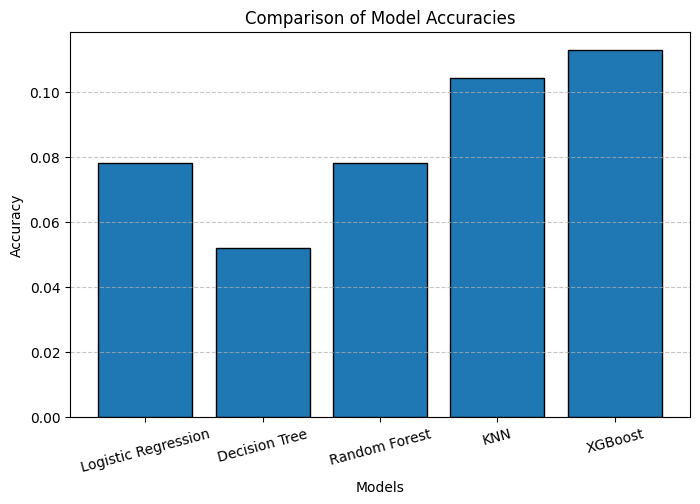

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(accuracy["Model"], accuracy["Accuracy"], edgecolor="black")

plt.title("Comparison of Model Accuracies")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()